Đang huấn luyện mạng LSTM...
Đang huấn luyện mạng RNN truyền thống...
Hoàn thành quá trình huấn luyện!

================== THỐNG KÊ KẾT QUẢ KHI TEST ==================
Mô hình mạng cải tiến LSTM MSE : 0.202553
Mô hình mạng truyền thống RNN MSE: 0.254267


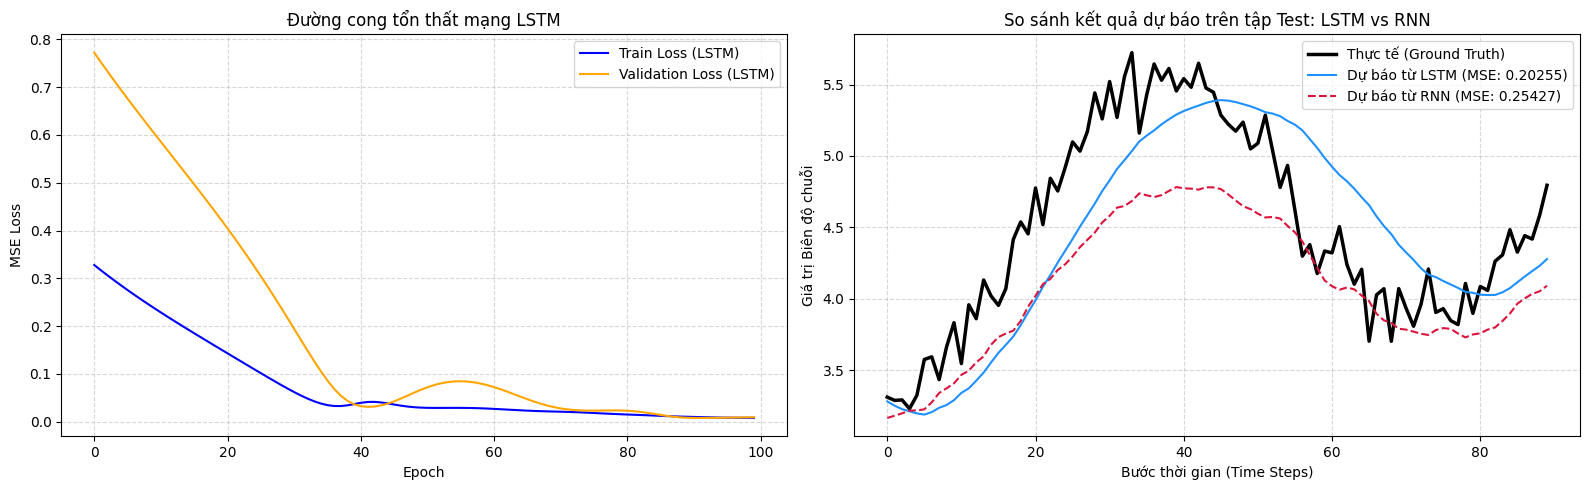

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# SETUP HỆ THỐNG & KHỞI TẠO CHUỖI DỮ LIỆU ĐỘNG
# ---------------------------------------------------------
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Khởi tạo chuỗi thời gian gồm 600 bước theo đúng công thức đề bài
time_steps = 600
t = np.linspace(0, 50, time_steps)
series_data = np.sin(t) + 0.1 * t + 0.15 * np.random.randn(time_steps)

# Chia tỷ lệ tập dữ liệu theo quy định
n_train = int(0.70 * time_steps) # 70% Train (420 mẫu)
n_val = int(0.15 * time_steps)   # 15% Validation (90 mẫu)
# 15% còn lại dành cho tập Test (90 mẫu)

# Chuẩn hóa MinMax về đoạn [0, 1] dựa trên thông số tập Train để chống rò rỉ thông tin
min_val = series_data[:n_train].min()
max_val = series_data[:n_train].max()
scaled_data = (series_data - min_val) / (max_val - min_val)

# Hàm tạo cửa sổ trượt thời gian (Sliding Window) cho chuỗi đơn biến
def make_time_windows(data, seq_len):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    return np.array(X), np.array(y)

seq_len = 20 # Độ dài cửa sổ nhìn lại quá khứ
X_arr, y_arr = make_time_windows(scaled_data, seq_len)

# Đóng gói và chuyển đổi sang PyTorch Tensors 3D dạng: (batch_size, seq_len, input_size=1)
X_train = torch.tensor(X_arr[:n_train-seq_len], dtype=torch.float32).unsqueeze(-1).to(device)
y_train = torch.tensor(y_arr[:n_train-seq_len], dtype=torch.float32).unsqueeze(1).to(device)

X_val = torch.tensor(X_arr[n_train-seq_len:n_train+n_val-seq_len], dtype=torch.float32).unsqueeze(-1).to(device)
y_val = torch.tensor(y_arr[n_train-seq_len:n_train+n_val-seq_len], dtype=torch.float32).unsqueeze(1).to(device)

X_test = torch.tensor(X_arr[n_train+n_val-seq_len:], dtype=torch.float32).unsqueeze(-1).to(device)
y_test = torch.tensor(y_arr[n_train+n_val-seq_len:], dtype=torch.float32).unsqueeze(1).to(device)

# ---------------------------------------------------------
# ĐỊNH NGHĨA HAI KIẾN TRÚC MẠNG SỌ SÁNH
# ---------------------------------------------------------

# 1. Mô hình sử dụng mạng cải tiến LSTM
class TimeSeriesLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=32, batch_first=True)
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        # out có kích thước: (batch_size, seq_len, hidden_size)
        out, (h_n, c_n) = self.lstm(x)
        # Lấy trạng thái ẩn tại bước thời gian cuối cùng của chuỗi tuần tự để dự báo
        return self.fc(out[:, -1, :])

# 2. Mô hình sử dụng mạng truyền thống RNN thuần túy
class TimeSeriesRNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.rnn = nn.RNN(input_size=1, hidden_size=32, batch_first=True)
        self.fc = nn.Linear(32, 1)

    def forward(self, x):
        out, h_n = self.rnn(x)
        return self.fc(out[:, -1, :])

# ---------------------------------------------------------
# QUY TRÌNH HUÂN LUYỆN TỔNG QUÁT (100 EPOCH)
# ---------------------------------------------------------
def train_time_series_model(model, epochs=100, lr=0.001):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)

    train_history = []
    val_history = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()

        # Đánh giá nhanh trên tập Validation
        model.eval()
        with torch.no_grad():
            val_outputs = model(X_val)
            v_loss = criterion(val_outputs, y_val)

        train_history.append(loss.item())
        val_history.append(v_loss.item())

    return model, train_history, val_history

# Huấn luyện hai mô hình một cách độc lập
print("Đang huấn luyện mạng LSTM...")
lstm_net, lstm_train_loss, lstm_val_loss = train_time_series_model(TimeSeriesLSTM().to(device))

print("Đang huấn luyện mạng RNN truyền thống...")
rnn_net, rnn_train_loss, rnn_val_loss = train_time_series_model(TimeSeriesRNN().to(device))

print("Hoàn thành quá trình huấn luyện!")

# ---------------------------------------------------------
# DỰ BÁO TRÊN TẬP TEST & KHỬ CHUẨN HÓA (INVERSE SCALE)
# ---------------------------------------------------------
lstm_net.eval()
rnn_net.eval()

with torch.no_grad():
    lstm_preds_scaled = lstm_net(X_test).cpu().numpy()
    rnn_preds_scaled = rnn_net(X_test).cpu().numpy()

# Khôi phục dữ liệu về miền giá trị thực tế ban đầu trước khi tính sai số
y_test_original = y_test.cpu().numpy() * (max_val - min_val) + min_val
lstm_predictions = lstm_preds_scaled * (max_val - min_val) + min_val
rnn_predictions = rnn_preds_scaled * (max_val - min_val) + min_val

# Tính toán sai số bình phương trung bình thực tế trên tập dữ liệu Test
lstm_mse = np.mean((y_test_original - lstm_predictions) ** 2)
rnn_mse = np.mean((y_test_original - rnn_predictions) ** 2)

print("\n================== THỐNG KÊ KẾT QUẢ KHI TEST ==================")
print(f"Mô hình mạng cải tiến LSTM MSE : {lstm_mse:.6f}")
print(f"Mô hình mạng truyền thống RNN MSE: {rnn_mse:.6f}")

# ---------------------------------------------------------
# TRỰC QUAN HÓA SO SÁNH ĐỒ THỊ DỰ BÁO
# ---------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Đồ thị 1: Lịch sử giảm tổn thất của mô hình LSTM
ax1.plot(lstm_train_loss, label='Train Loss (LSTM)', color='blue')
ax1.plot(lstm_val_loss, label='Validation Loss (LSTM)', color='orange')
ax1.set_title('Đường cong tổn thất mạng LSTM')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('MSE Loss')
ax1.grid(True, linestyle='--', alpha=0.5)
ax1.legend()

# Đồ thị 2: So sánh chuỗi dự báo thực tế trên tập Test
ax2.plot(y_test_original, label='Thực tế (Ground Truth)', color='black', linewidth=2.5)
ax2.plot(lstm_predictions, label=f'Dự báo từ LSTM (MSE: {lstm_mse:.5f})', color='dodgerblue', linestyle='-')
ax2.plot(rnn_predictions, label=f'Dự báo từ RNN (MSE: {rnn_mse:.5f})', color='crimson', linestyle='--')
ax2.set_title('So sánh kết quả dự báo trên tập Test: LSTM vs RNN')
ax2.set_xlabel('Bước thời gian (Time Steps)')
ax2.set_ylabel('Giá trị Biên độ chuỗi')
ax2.grid(True, linestyle='--', alpha=0.5)
ax2.legend()

plt.tight_layout()
plt.show()

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence
import numpy as np
from collections import Counter
from sklearn.metrics import accuracy_score, classification_report

# ---------------------------------------------------------
# SETUP HỆ THỐNG & TỰ KHỞI TẠO BỘ DỮ LIỆU SENTIMENT (> 1000 MẪU)
# ---------------------------------------------------------
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Khởi tạo tập ngữ liệu mẫu cơ bản (1: Tích cực, 0: Tiêu cực)
base_corpus = [
    ("phim xem rất hay và ý nghĩa", 1),
    ("mình rất thích nội dung này", 1),
    ("giao hàng nhanh đóng gói cẩn thận", 1),
    ("sản phẩm tuyệt vời lắm nha", 1),
    ("dịch vụ chất lượng tốt đáng tiền", 1),
    ("phim xem cực kỳ dở tệ", 0),
    ("nội dung quá chán thất vọng lắm", 0),
    ("giao hàng chậm trễ hộp bị móp", 0),
    ("chất lượng kém không đáng mua", 0),
    ("phí tiền mua bực mình vào người", 0)
]

# Nhân bản bộ dữ liệu lên để đạt quy mô lớn (> 1000 mẫu) theo yêu cầu đề bài
raw_corpus = base_corpus * 120 # Tạo ra 1200 mẫu dữ liệu văn bản

# Tách từ (Tokenize) bằng phương pháp đơn giản split()
tokens_list = [text.split() for text, label in raw_corpus]
labels_list = [label for text, label in raw_corpus]

# ---------------------------------------------------------
# XÂY DỰNG TỪ ĐIỂN (VOCABULARY)
# ---------------------------------------------------------
word_counts = Counter([word for tokens in tokens_list for word in tokens])
# Thêm token đặc biệt: <pad> để lấp đầy chuỗi, <unk> cho từ hiếm/lạ
vocab = {"<pad>": 0, "<unk>": 1}
for word in word_counts:
    vocab[word] = len(vocab)

# Chuyển đổi các từ trong câu thành chuỗi chỉ số ID tương ứng
X_sequences = [torch.tensor([vocab.get(word, 1) for word in tokens], dtype=torch.long) for tokens in tokens_list]
y_tensor = torch.tensor(labels_list, dtype=torch.long).to(device)

# Lưu lại độ dài thực tế của từng câu trước khi thực hiện Pad dữ liệu
lengths = torch.tensor([len(seq) for seq in X_sequences], dtype=torch.long)

# Thực hiện đệm (Padding) các câu ngắn theo câu dài nhất trong lô (Batch)
X_padded = pad_sequence(X_sequences, batch_first=True, padding_value=0)

# ---------------------------------------------------------
# CHIA TẬP DỮ LIỆU TRAIN / TEST (Tỷ lệ 80% / 20%)
# ---------------------------------------------------------
n_train = int(0.80 * len(raw_corpus))

X_train = X_padded[:n_train].to(device)
y_train = y_tensor[:n_train]
len_train = lengths[:n_train]

X_test = X_padded[n_train:].to(device)
y_test = y_tensor[n_train:]
len_test = lengths[n_train:]

# =========================================================
# XÂY DỰNG MẠNG PHÂN LOẠI BIDIRECTIONAL LSTM
# =========================================================
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=32, hidden_dim=32):
        super().__init__()
        # padding_idx=0 giúp mạng bỏ qua việc tính toán gradient cho token <pad>
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # Thiết lập cấu hình mạng LSTM hai chiều (bidirectional=True)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True, bidirectional=True)

        # Vì là mạng Bidirectional nên kích thước đầu vào lớp Tuyến tính phải nhân đôi: hidden_dim * 2
        self.fc = nn.Sequential(
            nn.Dropout(p=0.3),
            nn.Linear(hidden_dim * 2, 2) # Đầu ra phân 2 lớp (Tích cực/Tiêu cực)
        )

    def forward(self, x, lengths):
        # 1. Đi qua tầng nhúng từ (Embedding)
        embeds = self.embedding(x)

        # 2. KỸ THUẬT PACKING: Nén khối dữ liệu đệm lại để loại bỏ tính toán thừa trên các token <pad>
        packed_embeds = pack_padded_sequence(embeds, lengths.cpu(), batch_first=True, enforce_sorted=False)

        # 3. Đi qua tầng mạng Bidirectional LSTM
        packed_output, (h_n, c_n) = self.lstm(packed_embeds)

        # 4. TRÍCH XUẤT TRẠNG THÁI ẨN CUỐI CÙNG: Gộp chiều xuôi và chiều ngược
        # h_n có kích thước: (2 * num_layers, batch_size, hidden_dim)
        # h_n[-2] lấy hidden state cuối cùng của chiều xuôi (Forward)
        # h_n[-1] lấy hidden state cuối cùng của chiều ngược (Backward)
        h_combined = torch.cat([h_n[-2], h_n[-1]], dim=1)

        # 5. Phân lớp đầu ra
        return self.fc(h_combined)

# Khởi tạo mô hình, hàm loss mục tiêu và bộ tối ưu hóa Adam
model = BiLSTMClassifier(vocab_size=len(vocab)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.005)

# ---------------------------------------------------------
# QUY TRÌNH HUÂN LUYỆN (15 EPOCH)
# ---------------------------------------------------------
epochs = 15
print("--- BẮT ĐẦU HUẤN LUYỆN MẠNG BILSTM ---")

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    # Truyền đồng thời dữ liệu đệm và tensor độ dài thực tế vào mô hình
    logits = model(X_train, len_train)
    loss = criterion(logits, y_train)

    loss.backward()
    optimizer.step()

    if (epoch + 1) % 3 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] -> Training Loss: {loss.item():.4f}")

# ---------------------------------------------------------
# ĐÁNH GIÁ HIỆU NĂNG TRÊN TẬP TEST
# ---------------------------------------------------------
model.eval()
with torch.no_grad():
    test_logits = model(X_test, len_test)
    predictions = test_logits.argmax(dim=1).cpu().numpy()

y_test_np = y_test.cpu().numpy()

print("\n================ BÁO CÁO KẾT QUẢ PHÂN LOẠI ================")
print(f"Độ chính xác tổng thể (Accuracy Score): {accuracy_score(y_test_np, predictions)*100:.2f}%")
print("\nBảng chỉ số chi tiết (Classification Report):")
print(classification_report(y_test_np, predictions, target_names=['Tiêu cực (0)', 'Tích cực (1)']))

--- BẮT ĐẦU HUẤN LUYỆN MẠNG BILSTM ---
Epoch [3/15] -> Training Loss: 0.6075
Epoch [6/15] -> Training Loss: 0.4465
Epoch [9/15] -> Training Loss: 0.2787
Epoch [12/15] -> Training Loss: 0.1300
Epoch [15/15] -> Training Loss: 0.0463

================ BÁO CÁO KẾT QUẢ PHÂN LOẠI ================
Độ chính xác tổng thể (Accuracy Score): 100.00%

Bảng chỉ số chi tiết (Classification Report):
              precision    recall  f1-score   support

Tiêu cực (0)       1.00      1.00      1.00       120
Tích cực (1)       1.00      1.00      1.00       120

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

# ---------------------------------------------------------
# SETUP HỆ THỐNG & CHUẨN BỊ TẬP NGỮ LIỆU (CORPUS)
# ---------------------------------------------------------
torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Đoạn văn bản mẫu làm tập dữ liệu học (Dùng vài câu thơ trong Truyện Kiều)
text_corpus = """
Tram nam trong coi nguoi ta, Chu tai chu menh kheo la ghet nhau.
Trai qua mot cuoc be dau, Nhung dieu trong thay ma dau don long.
La gi bi sac tu phong, Troi xanh quen thoi ma hong danh ghen.
"""

# 1. Xây dựng bộ từ vựng (Vocab) gồm tất cả các ký tự duy nhất xuất hiện
char_vocab = sorted(list(set(text_corpus)))
vocab_size = len(char_vocab)

# Bản đồ chuyển đổi qua lại giữa Ký tự và Chỉ số ID
char_to_idx = {ch: i for i, ch in enumerate(char_vocab)}
idx_to_char = {i: ch for i, ch in enumerate(char_vocab)}

# 2. Tạo dữ liệu huấn luyện dạng cửa sổ trượt ký tự
seq_length = 20 # Độ dài chuỗi ký tự đầu vào nhìn lại quá khứ
X_data = []
y_data = []

for i in range(len(text_corpus) - seq_length):
    # Input: chuỗi 20 ký tự liên tiếp
    X_data.append([char_to_idx[ch] for ch in text_corpus[i:i+seq_length]])
    # Target: Ký tự thứ 21 ngay kế tiếp chuỗi đó
    y_data.append(char_to_idx[text_corpus[i+seq_length]])

# Chuyển đổi sang định dạng PyTorch Tensors
X_tensor = torch.tensor(X_data, dtype=torch.long).to(device)
y_tensor = torch.tensor(y_data, dtype=torch.long).to(device)

# ---------------------------------------------------------
# XÂY DỰNG KIẾN TRÚC MẠNG CHARACTER-LEVEL LSTM (2 TẦNG)
# ---------------------------------------------------------
class CharLSTMGenerator(nn.Module):
    def __init__(self, vocab_size, embed_dim=32, hidden_dim=128):
        super().__init__()
        # Tầng nhúng ký tự (Embedding)
        self.embedding = nn.Embedding(vocab_size, embed_dim)

        # Mạng LSTM gồm 2 tầng xếp chồng lên nhau (num_layers=2) theo yêu cầu
        self.lstm = nn.LSTM(embed_dim, hidden_dim, num_layers=2, batch_first=True)

        # Lớp tuyến tính ánh xạ không gian trạng thái ẩn về số lượng ký tự trong từ điển
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x):
        # x shape: (batch_size, seq_length)
        embeds = self.embedding(x) # shape: (batch_size, seq_length, embed_dim)

        # out shape: (batch_size, seq_length, hidden_dim)
        out, _ = self.lstm(embeds)

        # Chỉ lấy đầu ra của bước thời gian cuối cùng trong chuỗi để dự đoán ký tự tiếp theo
        return self.fc(out[:, -1, :])

# Khởi tạo mô hình
model = CharLSTMGenerator(vocab_size=vocab_size).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# ---------------------------------------------------------
# VÒNG LẶP HUẤN LUYỆN MÔ HÌNH (120 EPOCH)
# ---------------------------------------------------------
epochs = 120
print("--- BẮT ĐẦU HUẤN LUYỆN MÔ HÌNH SINH VĂN BẢN (120 EPOCH) ---")

for epoch in range(epochs):
    model.train()
    optimizer.zero_grad()

    logits = model(X_tensor)
    loss = criterion(logits, y_tensor)

    loss.backward()
    optimizer.step()

    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{epochs}] -> CrossEntropy Loss: {loss.item():.4f}")

# ---------------------------------------------------------
# HÀM SINH VĂN BẢN DỰA TRÊN NHIỆT ĐỘ (TEMPERATURE SAMPLING)
# ---------------------------------------------------------
def generate_text(seed_str, gen_len=80, temperature=0.6):
    model.eval()

    # Đảm bảo câu mồi có độ dài khớp với seq_length bằng cách cắt lấy phần đuôi
    seed_processed = seed_str[-seq_length:]
    current_input = [char_to_idx[ch] for ch in seed_processed]

    generated_text = seed_str

    with torch.no_grad():
        for _ in range(gen_len):
            # Chuyển mảng đầu vào hiện tại thành tensor đưa vào mạng dự báo
            x_in = torch.tensor([current_input], dtype=torch.long).to(device)
            logits = model(x_in).squeeze(0).cpu().numpy()

            # Kỹ thuật Temperature Sampling: Điều chỉnh phân phối xác suất
            # Công thức toán học: prob = softmax(logits / temperature)
            exp_logits = np.exp(logits / temperature)
            probs = exp_logits / np.sum(exp_logits)

            # Chọn ngẫu nhiên một ký tự dựa trên phân phối xác suất đã điều chỉnh
            next_char_idx = np.random.choice(len(char_vocab), p=probs)
            next_char = idx_to_char[next_char_idx]

            # Ghép ký tự vừa dự đoán vào chuỗi kết quả
            generated_text += next_char

            # Cập nhật cửa sổ trượt: Bỏ ký tự đầu tiên, thêm ký tự mới vào cuối
            current_input = current_input[1:] + [next_char_idx]

    return generated_text

# ---------------------------------------------------------
# HIỂN THỊ KẾT QUẢ THỬ NGHIỆM SINH THƠ
# ---------------------------------------------------------
print("\n================== KẾT QUẢ SINH VĂN BẢN TỰ ĐỘNG ==================")
# Dùng câu mồi ban đầu
seed = "Tram nam trong coi ngu"
print(f"Câu mồi (Seed): \"{seed}\"")
print("-" * 65)
print(generate_text(seed_str=seed, gen_len=85, temperature=0.6))
print("=" * 65)

--- BẮT ĐẦU HUẤN LUYỆN MÔ HÌNH SINH VĂN BẢN (120 EPOCH) ---
Epoch [20/120] -> CrossEntropy Loss: 1.1413
Epoch [40/120] -> CrossEntropy Loss: 0.0458
Epoch [60/120] -> CrossEntropy Loss: 0.0039
Epoch [80/120] -> CrossEntropy Loss: 0.0018
Epoch [100/120] -> CrossEntropy Loss: 0.0013
Epoch [120/120] -> CrossEntropy Loss: 0.0011

================== KẾT QUẢ SINH VĂN BẢN TỰ ĐỘNG ==================
Câu mồi (Seed): "Tram nam trong coi ngu"
-----------------------------------------------------------------
Tram nam trong coi nguoi ta, Chu tai chu menh kheo la ghet nhau.
Trai qua mot cuoc be dau, Nhung dieu trong
